In [1]:
import pandas as pd
import numpy as np

nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code","date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

In [2]:
results=[]

for code,df in nav.groupby("amfi_code"):

    r=df["daily_return"].dropna()

    var=np.percentile(r,5)

    cvar=r[r<=var].mean()

    results.append({
        "amfi_code":code,
        "VaR95":var,
        "CVaR95":cvar
    })

var_report=pd.DataFrame(results)

var_report.to_csv(
    "../data/processed/var_cvar_report.csv",
    index=False
)

In [3]:
import matplotlib.pyplot as plt

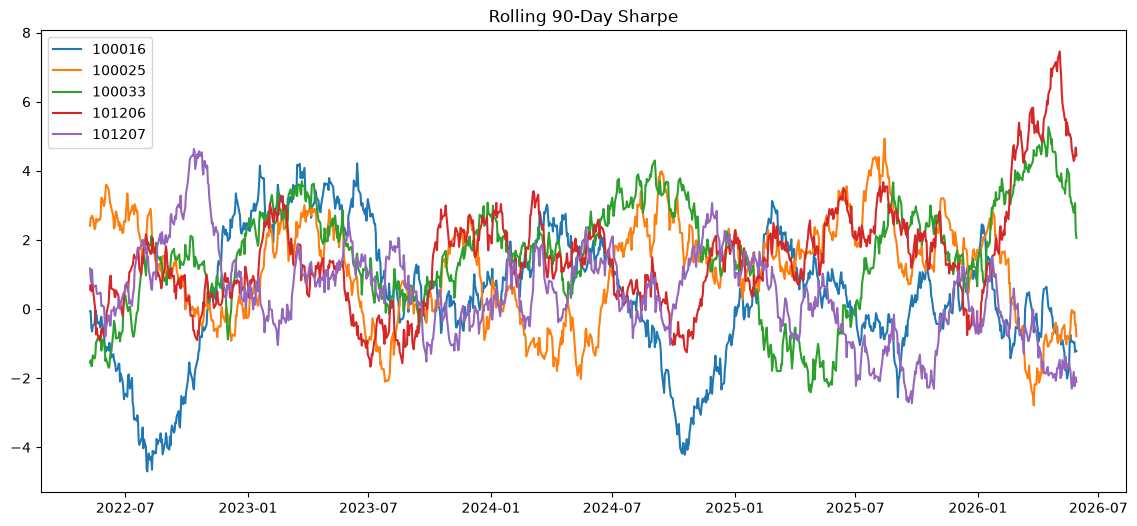

In [4]:
funds=nav["amfi_code"].unique()[:5]

plt.figure(figsize=(14,6))

for fund in funds:

    df=nav[
        nav["amfi_code"]==fund
    ].copy()

    rolling=(
        df["daily_return"]
        .rolling(90)
        .mean()
        /
        df["daily_return"]
        .rolling(90)
        .std()
    )*np.sqrt(252)

    plt.plot(
        df["date"],
        rolling,
        label=fund
    )

plt.legend()

plt.title("Rolling 90-Day Sharpe")

plt.savefig(
"../reports/charts/rolling_sharpe_chart.png"
)

plt.show()

In [5]:
transactions=pd.read_csv(
"../data/processed/investor_transactions_cleaned.csv"
)

transactions["transaction_date"]=pd.to_datetime(
transactions["transaction_date"]
)

In [6]:
transactions["cohort"]=(
transactions.groupby("investor_id")
["transaction_date"]
.transform("min")
.dt.year
)

In [7]:
cohort=transactions.groupby(
"cohort"
).agg(

Average_SIP=("amount_inr","mean"),

Total_Investment=("amount_inr","sum")

)

cohort

,Average_SIP,Total_Investment
cohort,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


In [8]:
top=transactions.groupby(
["cohort","amfi_code"]
).size()

top=top.groupby(level=0).idxmax()

top

cohort
2024    (2024, 148568)
2025    (2025, 119599)
dtype: object

In [9]:
sip=transactions[
transactions["transaction_type"]=="SIP"
]

In [10]:
gap=[]

for inv,df in sip.groupby("investor_id"):

    if len(df)<6:
        continue

    df=df.sort_values(
    "transaction_date"
    )

    avg_gap=(
    df["transaction_date"]
    .diff()
    .dt.days
    .mean()
    )

    gap.append({

    "investor_id":inv,

    "avg_gap":avg_gap,

    "status":
    "At Risk"
    if avg_gap>35
    else "Healthy"

    })

gap=pd.DataFrame(gap)

In [19]:
portfolio["weight"] = portfolio["weight_pct"] / 100

In [20]:
sector_weights = (

portfolio.groupby(

["amfi_code","sector"]

)["weight"]

.sum()

.reset_index()

)

sector_weights.head()

,amfi_code,sector,weight
0,100016,Automobile,0.1484
1,100016,Banking,0.0339
2,100016,Energy,0.0609
3,100016,FMCG,0.1168
4,100016,IT,0.2590


In [21]:
hhi = (

sector_weights.groupby(

"amfi_code"

)["weight"]

.apply(

lambda x: (x**2).sum()

)

.reset_index(name="HHI")

)

In [27]:
performance = pd.read_csv(
    "../data/processed/scheme_performance_cleaned.csv"
)

In [28]:
hhi = hhi.merge(

performance[
[
"amfi_code",
"scheme_name",
"fund_house",
"category"
]
],

on="amfi_code"

)

hhi = hhi.sort_values(

"HHI",

ascending=False

)

hhi.head()

,amfi_code,HHI,scheme_name,fund_house,category
11,119092,0.296769,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,Large Cap
30,148569,0.254992,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,ELSS
27,125498,0.253155,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,Mid Cap
6,102887,0.251383,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,Flexi Cap
32,149323,0.241077,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap


In [29]:
hhi.to_csv(

"../data/processed/hhi_report.csv",

index=False

)

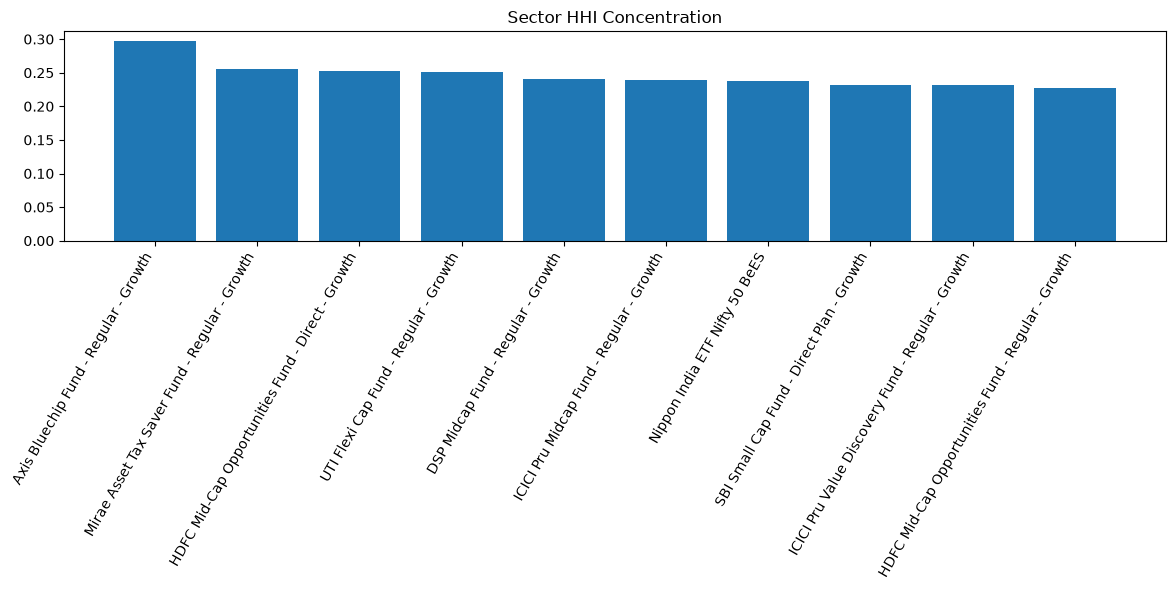

In [30]:
top10 = hhi.head(10)

plt.figure(figsize=(12,6))

plt.bar(

top10["scheme_name"],

top10["HHI"]

)

plt.xticks(rotation=60,ha="right")

plt.title(

"Sector HHI Concentration"

)

plt.tight_layout()

plt.savefig(

"../reports/charts/sector_hhi.png",

dpi=300

)

plt.show()